In [17]:
# %% [Célula 1]
import os
import urllib.parse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Carrega credenciais do .env e trata o caractere '@'
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
senha_segura = urllib.parse.quote_plus(DB_PASS)

DATABASE_URL = f"postgresql://{DB_USER}:{senha_segura}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

# Criando fisicamente a Tabela Agregada e a VIEW no PostgreSQL
with engine.connect() as conexao:
    conexao.execute(text("CREATE SCHEMA IF NOT EXISTS gold;"))
    
    # 1. TABELA AGREGADA (JOIN entre Viagem e Trecho)
    conexao.execute(text("DROP TABLE IF EXISTS gold.fato_viagens_trechos;"))
    query_tabela = """
        CREATE TABLE gold.fato_viagens_trechos AS
        SELECT 
            v.id_viagem,
            v.nome_orgao_superior,
            v.destinos,
            v.valor_total,
            v.duracao_dias,
            t.sequencia_trecho,
            t.destino_uf,
            t.meio_transporte
        FROM silver.silver_viagem v
        INNER JOIN silver.silver_trecho t ON v.id_viagem = t.id_viagem;
    """
    conexao.execute(text(query_tabela))
    
    # 2. VIEW (JOIN entre Viagem e Pagamento)
    conexao.execute(text("DROP VIEW IF EXISTS gold.vw_financeiro_pagamentos;"))
    query_view = """
        CREATE VIEW gold.vw_financeiro_pagamentos AS
        SELECT 
            v.id_viagem,
            v.nome_orgao_superior,
            p.nome_orgao_pagador,
            p.tipo_pagamento,
            p.valor AS valor_pagamento
        FROM silver.silver_viagem v
        INNER JOIN silver.silver_pagamento p ON v.id_viagem = p.id_viagem;
    """
    conexao.execute(text(query_view))
    conexao.commit()
    print("Camada Gold estruturada: Tabela e VIEW criadas com sucesso!")

Camada Gold estruturada: Tabela e VIEW criadas com sucesso!


--- TABELA: TOP 5 ÓRGÃOS COM MAIOR CUSTO TOTAL ---
                              nome_orgao_superior   custo_total
0       Ministério da Justiça e Segurança Pública  4.869331e+08
1                            Ministério da Defesa  1.560703e+08
2                          Ministério da Educação  1.112913e+08
3  Ministério do Meio Ambiente e Mudança do Clima  4.969771e+07
4                Ministério da Previdência Social  4.041731e+07


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_4824\1004704686.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='custo_total', y='nome_orgao_superior', palette='Blues_r')


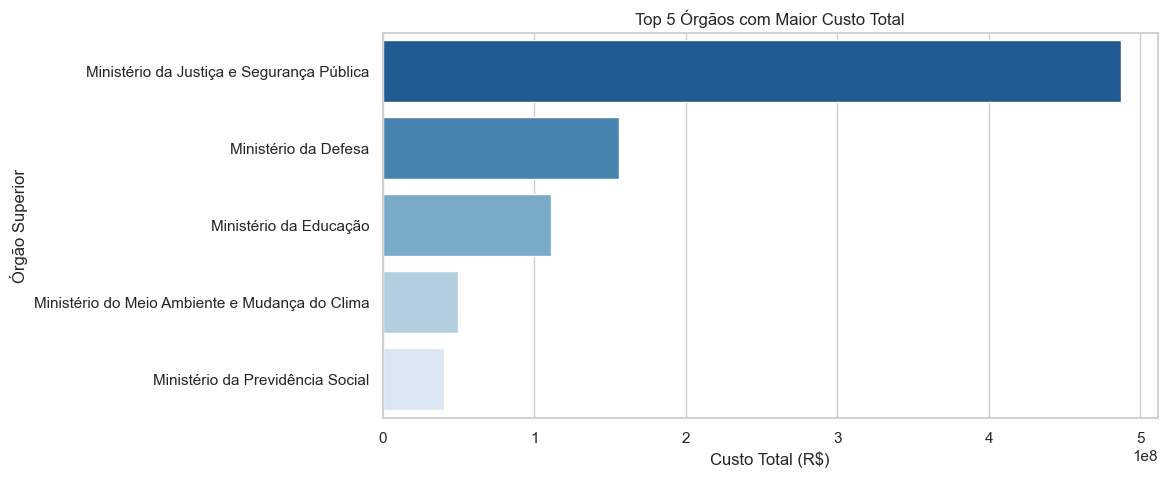

In [18]:
# %% [Célula 2]
query = """
    SELECT nome_orgao_superior, SUM(valor_total) as custo_total 
    FROM silver.silver_viagem 
    GROUP BY nome_orgao_superior ORDER BY custo_total DESC LIMIT 5;
"""
df = pd.read_sql(query, engine)
print("--- TABELA: TOP 5 ÓRGÃOS COM MAIOR CUSTO TOTAL ---")
print(df)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='custo_total', y='nome_orgao_superior', palette='Blues_r')
plt.title('Top 5 Órgãos com Maior Custo Total')
plt.xlabel('Custo Total (R$)')
plt.ylabel('Órgão Superior')

plt.savefig('grafico_1_orgaos_maior_custo.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# %% [Célula 3]
# Correção do Engenheiro: Extrai apenas a primeira localidade principal da string de destinos
query = """
    SELECT 
        TRIM(SPLIT_PART(destinos, ',', 1)) as destino_principal, 
        ROUND(AVG(valor_total)::numeric, 2) as custo_medio 
    FROM silver.silver_viagem 
    WHERE destinos IS NOT NULL AND destinos != ''
    GROUP BY TRIM(SPLIT_PART(destinos, ',', 1)) 
    HAVING COUNT(id_viagem) > 5 
    ORDER BY custo_medio DESC 
    LIMIT 3;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA CORRIGIDA: TOP 3 DESTINOS DISTINTOS COM MAIOR CUSTO MÉDIO ---")
print(df)

# Plotagem do gráfico corrigida sem os alertas de depreciação do Seaborn
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df, 
    x='custo_medio', 
    y='destino_principal', 
    hue='destino_principal', 
    palette='Oranges_r', 
    legend=False
)
plt.title('Top 3 Destinos Principais com Maior Custo Médio por Viagem')
plt.xlabel('Custo Médio (R$)')
plt.ylabel('Destino Principal')

# Salva o gráfico corrigido na raiz do projeto
plt.savefig('grafico_2_destinos_maior_custo_medio.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA ATUALIZADA: VIAGEM DE MAIOR DURAÇÃO VALIDA ---
             id_viagem                      nome_viajante  \
0  0000000000020793594  Informações protegidas por sigilo   

                            destinos  duracao_dias  valor_total  
0  Informações protegidas por sigilo           378     120650.0  

[Insight do Engenheiro] Viajante: Informações Protegidas Por Sigilo
Destino da Viagem: Informações protegidas por sigilo
Duração: 378 dias | Custo Total: R$ 120,650.00


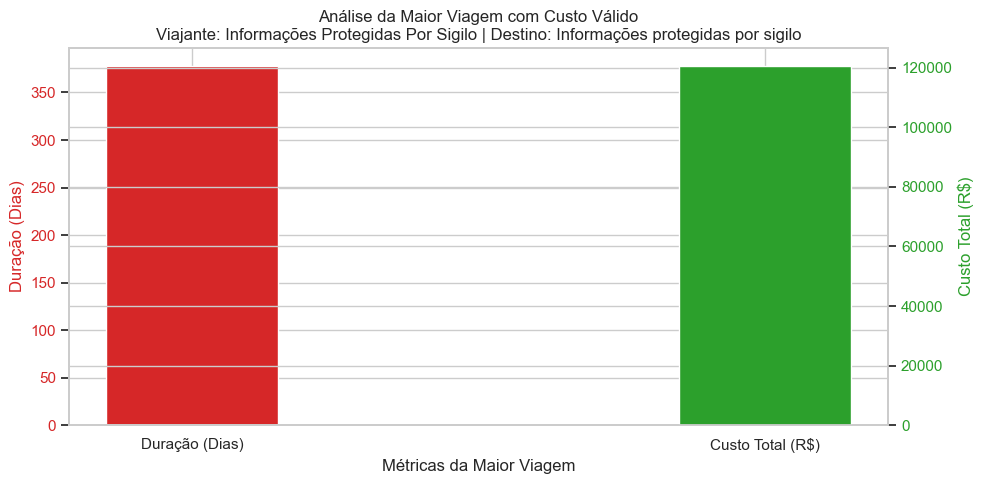

In [20]:
# %% [Célula 4]
# Query corrigida pelo Engenheiro: busca a maior duração onde o valor_total seja maior que zero
query = """
    SELECT id_viagem, nome_viajante, destinos, duracao_dias, valor_total 
    FROM silver.silver_viagem 
    WHERE valor_total > 0 AND duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC LIMIT 1;
"""
df = pd.read_sql(query, engine)

# Tratamento do nome da viajante e extração das variáveis
nome_cru = df['nome_viajante'][0]
viajante = str(nome_cru).title().strip() # Formata para "Nome Sobrenome" legível
destino = df['destinos'][0]
dias = int(df['duracao_dias'][0])
custo = float(df['valor_total'][0])

print("\n--- TABELA ATUALIZADA: VIAGEM DE MAIOR DURAÇÃO VALIDA ---")
print(df)
print(f"\n[Insight do Engenheiro] Viajante: {viajante}")
print(f"Destino da Viagem: {destino}")
print(f"Duração: {dias} dias | Custo Total: R$ {custo:,.2f}")

# Subplots para escalas diferentes (Eixo Duplo) para plotar Dias e R$ com perfeição
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Métricas da Maior Viagem')
ax1.set_ylabel('Duração (Dias)', color=color)
ax1.bar(['Duração (Dias)'], [dias], color=color, width=0.3)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Custo Total (R$)', color=color)
ax2.bar(['Custo Total (R$)'], [custo], color=color, width=0.3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Análise da Maior Viagem com Custo Válido\nViajante: {viajante} | Destino: {destino}')
fig.tight_layout()

plt.savefig('grafico_3_viagem_maior_duracao.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: VALOR MÉDIO POR TIPO DE PAGAMENTO ---
              tipo_pagamento  valor_medio
0                    DIÁRIAS      2078.28
1                   PASSAGEM      1878.34
2  Serviço correlato: seguro       447.51
3                RESTITUIÇÃO       245.70


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_4824\4094092421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='tipo_pagamento', y='valor_medio', palette='Greens_r')


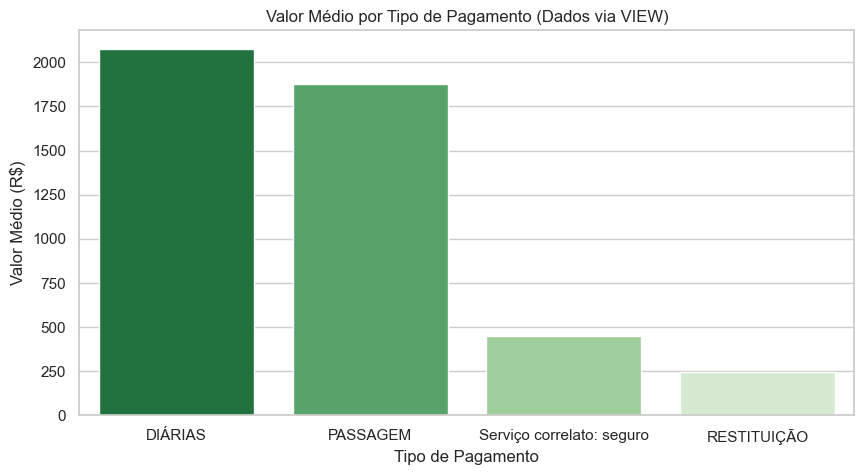

In [21]:
# %% [Célula 5]
query = """
    SELECT tipo_pagamento, ROUND(AVG(valor_pagamento)::numeric, 2) as valor_medio 
    FROM gold.vw_financeiro_pagamentos 
    GROUP BY tipo_pagamento ORDER BY valor_medio DESC;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA: VALOR MÉDIO POR TIPO DE PAGAMENTO ---")
print(df)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='tipo_pagamento', y='valor_medio', palette='Greens_r')
plt.title('Valor Médio por Tipo de Pagamento (Dados via VIEW)')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Valor Médio (R$)')

plt.savefig('grafico_4_pagamento_maior_valor_medio.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ---
   meio_transporte  quantidade_trechos
0  Veículo Oficial              386424
1            Aéreo              232666
2       Rodoviário               64970
3  Veículo Próprio               42846
4          Fluvial                8429
5      Ferroviário                 874
6         Marítimo                 481


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_4824\1786461755.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='quantidade_trechos', y='meio_transporte', palette='viridis')


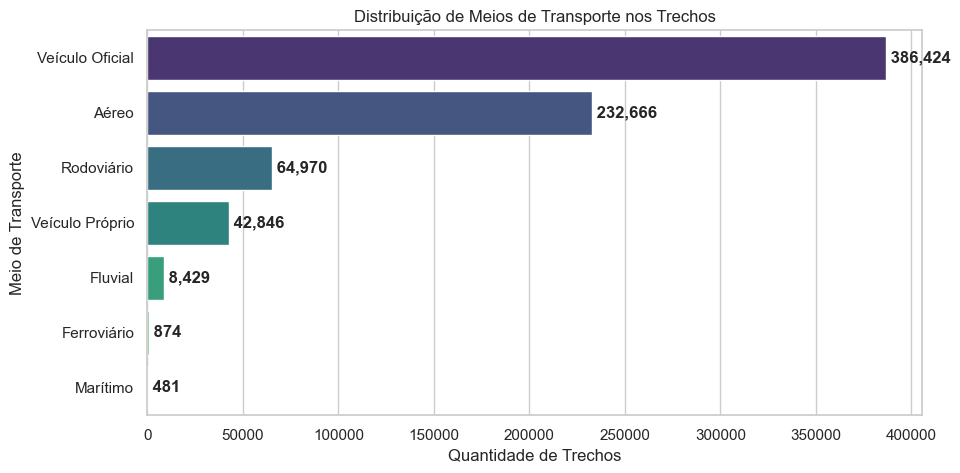

In [22]:
# %% [Célula 6]
query = """
    SELECT meio_transporte, COUNT(*) as quantidade_trechos 
    FROM gold.fato_viagens_trechos 
    WHERE meio_transporte IS NOT NULL 
      AND meio_transporte NOT IN ('Sem informação', 'Inválido', '')
    GROUP BY meio_transporte 
    ORDER BY quantidade_trechos DESC;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ---")
print(df)

# Substituição do Engenheiro: Gráfico de barras horizontais para eliminar sobreposição
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='quantidade_trechos', y='meio_transporte', palette='viridis')
plt.title('Distribuição de Meios de Transporte nos Trechos')
plt.xlabel('Quantidade de Trechos')
plt.ylabel('Meio de Transporte')

# Adiciona rótulos de texto com a contagem exata no final de cada barra
for index, value in enumerate(df['quantidade_trechos']):
    plt.text(value, index, f' {value:,}', va='center', fontweight='bold')

plt.savefig('grafico_5_meio_transporte_mais_usado.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: UF DE DESTINO COM MAIS TRECHOS ---
  destino_uf  total_trechos
0  São Paulo          82722


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_4824\2268534657.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_trechos', y='destino_uf', palette='Purples_r')


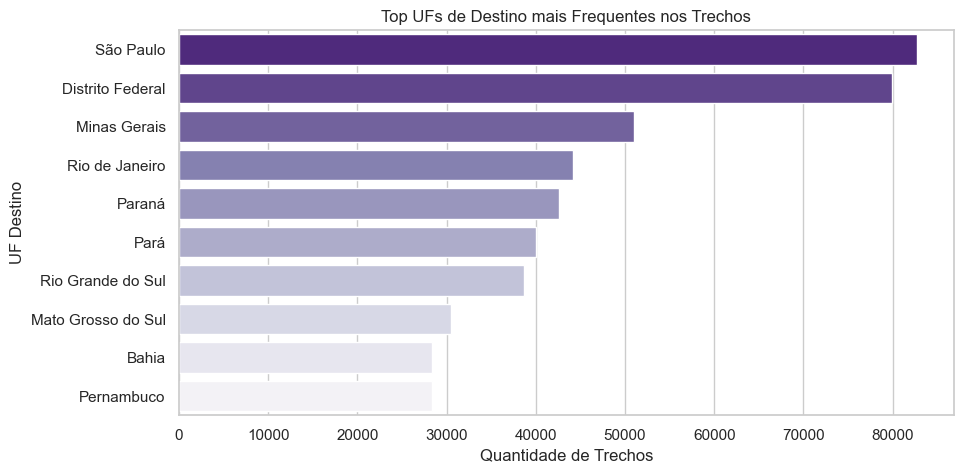

In [23]:
# %% [Célula 7]
query = """
    SELECT destino_uf, COUNT(*) as total_trechos 
    FROM gold.fato_viagens_trechos 
    WHERE destino_uf IS NOT NULL AND destino_uf != 'Sem informação'
    GROUP BY destino_uf ORDER BY total_trechos DESC LIMIT 10;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA: UF DE DESTINO COM MAIS TRECHOS ---")
print(df.head(1))

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='total_trechos', y='destino_uf', palette='Purples_r')
plt.title('Top UFs de Destino mais Frequentes nos Trechos')
plt.xlabel('Quantidade de Trechos')
plt.ylabel('UF Destino')

plt.savefig('grafico_6_uf_destino_mais_frequente.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: ÓRGÃO PAGADOR QUE MAIS PAGOU NO TOTAL ---
                    nome_orgao_pagador    total_pago
0  Fundo Nacional de Segurança Pública  2.784810e+08
1                             Sigiloso  2.004848e+08
2               Comando da Aeronáutica  8.176914e+07
3  Instituto Nacional do Seguro Social  3.742760e+07
4                  Comando do Exército  3.687264e+07


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_4824\1520707750.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_pago', y='nome_orgao_pagador', palette='YlOrRd_r')


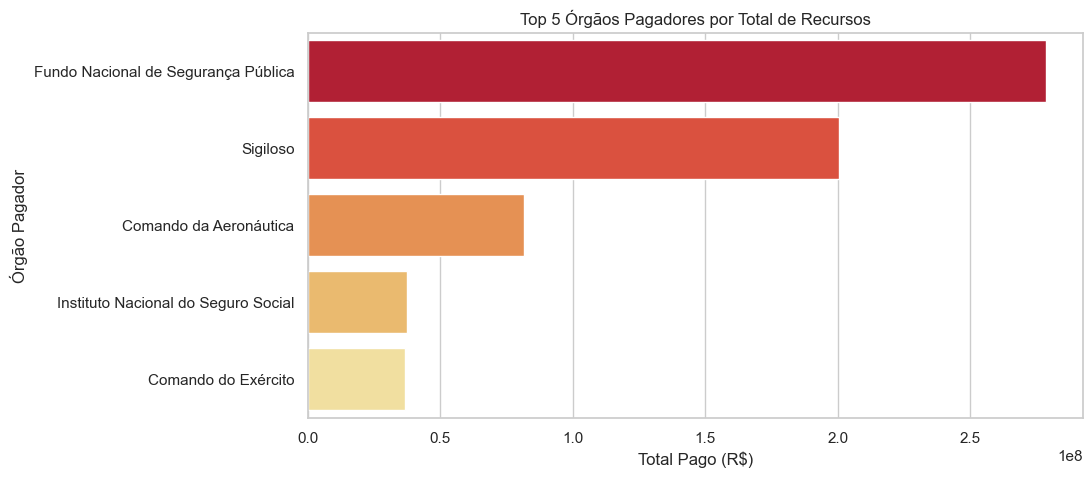

In [24]:
# %% [Célula 8]
query = """
    SELECT nome_orgao_pagador, SUM(valor_pagamento) as total_pago 
    FROM gold.vw_financeiro_pagamentos 
    GROUP BY nome_orgao_pagador ORDER BY total_pago DESC LIMIT 5;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA: ÓRGÃO PAGADOR QUE MAIS PAGOU NO TOTAL ---")
print(df)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='total_pago', y='nome_orgao_pagador', palette='YlOrRd_r')
plt.title('Top 5 Órgãos Pagadores por Total de Recursos')
plt.xlabel('Total Pago (R$)')
plt.ylabel('Órgão Pagador')

plt.savefig('grafico_7_orgao_pagador_maior_valor.png', dpi=300, bbox_inches='tight')
plt.show()